In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from sktime.forecasting.tbats import TBATS
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout

warnings.filterwarnings('ignore', category=FutureWarning)

tf.random.set_seed(42)
np.random.seed(42)

/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jchan/miniconda3/envs/sales_forecasting/lib/python3.12/site-packages/

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df = sales[['account_id', 'sales_channel_id']].value_counts()
df = pd.DataFrame(df).reset_index()

In [4]:
EPOCHS = 1000
BATCH_SIZE = 32
VALID_SPLIT = 0.1

In [5]:
LOOKBACK = 3
SEASONAL_PERIODS = (24, 24*7)
COVERAGE = 0.2
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [6]:
# ####
# LOOKBACK = 3
# SEASONAL_PERIODS = (24, 24*7)
# COVERAGE = 0.35
# END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
# TEST_SIZE = 24

# OOT_DATE = END_DATE + timedelta(hours=13)
# ####

In [7]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [8]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [9]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

In [10]:
# ####
# sales.drop('sales_channel_id', axis=1, inplace=True)
# df = sales['account_id'].value_counts()
# df = pd.DataFrame(df).reset_index()

# df
# ####

In [11]:
# ### ALL

# summary_dict = {}
# id_pairs = list(df['account_id'])
# for account_id in tqdm(id_pairs):
#     account_id = 'f9129295-bb08-4330-b60c-9f0beadda521'
#     print(f'account_id: {account_id}')
    
#     summary_dict[account_id] = {}
    
#     cond = sales['account_id'] == account_id
#     df_client = sales[cond].drop('account_id', axis=1)
#     df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
#     df_client = df_client.sort_values('created_date').reset_index(drop=True)
#     df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)
    
#     df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
#     df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')
    
#     end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
#     start_date = end_date - relativedelta(months=LOOKBACK)
#     date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
#     df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')
    
#     forecast_dict = {}
    
#     for n, col in enumerate(['price_total_agg', 'n_orders']):
#         print(col)
        
#         summary_dict[account_id][f'dataset_{n}'] = {}
#         summary_dict[account_id][f'dataset_{n}']['name'] = col
        
#         forecast_dict[f'dataset_{n}'] = {}
        
#         df = df_client_mod[col]
        
#         df.fillna(0, inplace=True)
        
#         df_train = df.iloc[:-TEST_SIZE]
#         df_test = df.iloc[-TEST_SIZE:]
        
#         tbats = TBATS(sp=[24, 168], show_warnings=False, n_jobs=-1)
#         tbats.fit(df_train)
        
#         forecast = tbats.predict(fh=df.index)
#         forecast_int = tbats.predict_interval(fh=df.index, coverage=COVERAGE)
        
#         forecast_dict[f'dataset_{n}']['forecast'] = forecast[-TEST_SIZE:]
#         forecast_dict[f'dataset_{n}']['forecast_lower'] = forecast_int.iloc[-TEST_SIZE:, 0]
#         forecast_dict[f'dataset_{n}']['forecast_upper'] = forecast_int.iloc[-TEST_SIZE:, 1]
        
#         oot_forecast = tbats.predict(fh=df_oot.index)
#         oot_forecast_int = tbats.predict_interval(fh=df_oot.index, coverage=COVERAGE)
        
#         forecast_dict[f'dataset_{n}']['oot_forecast'] = oot_forecast
#         forecast_dict[f'dataset_{n}']['oot_forecast_lower'] = oot_forecast_int.iloc[:, 0]
#         forecast_dict[f'dataset_{n}']['oot_forecast_upper'] = oot_forecast_int.iloc[:, 1]
        
#         train_pred = forecast[:-TEST_SIZE]
#         train_mae = mean_absolute_error(df_train, train_pred)
#         train_rmse = root_mean_squared_error(df_train, train_pred)
        
#         print(f"train RMSE: {train_rmse:.3f}")
#         print(f"train MAE:  {train_mae:.3f}")
        
#         test_pred = forecast[-TEST_SIZE:]
#         test_mae = mean_absolute_error(df_test, test_pred)
#         test_rmse = root_mean_squared_error(df_test, test_pred)

#         print(f"test RMSE: {test_rmse:.3f}")
#         print(f"test MAE:  {test_mae:.3f}")
        
#         summary_dict[account_id][f'dataset_{n}']['train RMSE'] = train_rmse
#         summary_dict[account_id][f'dataset_{n}']['test RMSE'] = test_rmse
#         summary_dict[account_id][f'dataset_{n}']['train MAE'] = train_mae
#         summary_dict[account_id][f'dataset_{n}']['test MAE'] = test_mae
        
#         plt.figure(figsize=(12, 3))
#         sns.lineplot(df_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
#         sns.lineplot(forecast[-6*TEST_SIZE:-TEST_SIZE].squeeze(), lw=0.8, label='Estimation')
#         sns.lineplot(df_test, lw=0.8, label='Test')
#         sns.lineplot(forecast[-TEST_SIZE:].squeeze(), lw=0.8, label='Forecast')
#         sns.lineplot(forecast_int.iloc[-TEST_SIZE:, 0], c='darkviolet', linestyle='--', lw=0.8)
#         sns.lineplot(forecast_int.iloc[-TEST_SIZE:, 1], c='darkviolet', linestyle='--', lw=0.8)
#         sns.lineplot(2*forecast_int.iloc[-TEST_SIZE:, 0]-forecast[-TEST_SIZE:].squeeze(), c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
#         sns.lineplot(2*forecast_int.iloc[-TEST_SIZE:, 1]-forecast[-TEST_SIZE:].squeeze(), c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
#         sns.lineplot(oot_forecast.squeeze(), lw=0.8, label='OOT Forecast')
#         sns.lineplot(oot_forecast_int.iloc[:, 0], c='darkviolet', linestyle='--', lw=0.8)
#         sns.lineplot(oot_forecast_int.iloc[:, 1], c='darkviolet', linestyle='--', lw=0.8)
#         plt.fill_between(x=forecast_int.index[-TEST_SIZE:],
#                          y1=forecast_int.iloc[-TEST_SIZE:, 0],
#                          y2=forecast_int.iloc[-TEST_SIZE:, 1],
#                          color='violet',
#                          alpha=0.5)
#         plt.fill_between(x=forecast_int.index[-TEST_SIZE:],
#                          y1=2*forecast_int.iloc[-TEST_SIZE:, 0]-forecast[-TEST_SIZE:].squeeze(),
#                          y2=2*forecast_int.iloc[-TEST_SIZE:, 1]-forecast[-TEST_SIZE:].squeeze(),
#                          color='violet',
#                          alpha=0.3)
#         plt.fill_between(x=oot_forecast_int.index,
#                          y1=oot_forecast_int.iloc[:, 0],
#                          y2=oot_forecast_int.iloc[:, 1],
#                          color='violet',
#                          alpha=0.5)
#         plt.legend()
#         plt.savefig(f'plots/time_series/forecast_{account_id}_all_{col}_ts.png')
#         plt.show();
    
#     with open(f'sql/time_series/forecast_{account_id}_all_ts.sql', 'w') as output_file:
#         pt_forecast_lower = forecast_dict['dataset_0']['forecast_lower']
#         pt_forecast_upper = forecast_dict['dataset_0']['forecast_upper']
#         pt_forecast = forecast_dict['dataset_0']['forecast']
        
#         no_forecast_lower = forecast_dict['dataset_1']['forecast_lower']
#         no_forecast_upper = forecast_dict['dataset_1']['forecast_upper']
#         no_forecast = forecast_dict['dataset_1']['forecast']
#         for i in range(len(df_test)):
#             start_time = df_test.index[i]
#             end_time = start_time + pd.Timedelta(hours=1)
#             output_file.write(
#                 f"""
#                 INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
#                                       channel, seller, account_id, organization_id, store_id, minutes_interval,
#                                       model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
#                 VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
#                         'ALL', 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
#                         {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
#                         {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
#                 """
#                 )
        
#         pt_oot_forecast_lower = forecast_dict['dataset_0']['oot_forecast_lower']
#         pt_oot_forecast_upper = forecast_dict['dataset_0']['oot_forecast_upper']
#         pt_oot_forecast = forecast_dict['dataset_0']['oot_forecast']
        
#         no_oot_forecast_lower = forecast_dict['dataset_1']['oot_forecast_lower']
#         no_oot_forecast_upper = forecast_dict['dataset_1']['oot_forecast_upper']
#         no_oot_forecast = forecast_dict['dataset_1']['oot_forecast']
#         for i in range(len(df_oot)):
#             start_time = df_oot.index[i]
#             end_time = start_time + pd.Timedelta(hours=1)
#             output_file.write(
#                 f"""
#                 INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
#                                       channel, seller, account_id, organization_id, store_id, minutes_interval,
#                                       model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
#                 VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
#                         'ALL', 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
#                         {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
#                         {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
#                 """
#             )

account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 3ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
train RMSE: 0.000
train MAE:  0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
test RMSE: 0.000
test MAE:  0.000
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
61/61 - 1s - 12ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━

,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


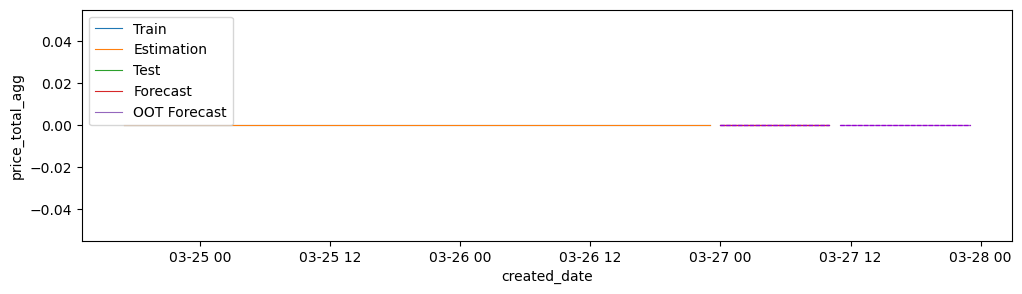

n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 11ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
60/60 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
train RMSE: 0.000
train MAE:  0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
test RMSE: 0.000
test MAE:  0.000
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
61/61 - 1s - 14ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/1000
61/61 - 0s - 2ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,feature,coef
0,tbats,0.0
1,gb,0.0
2,lstm,0.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


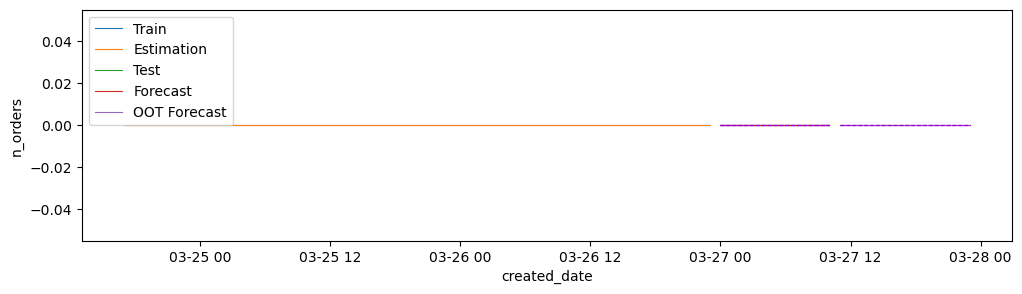

account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c
sales_channel_id: 1
price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Epoch 1/1000
60/60 - 1s - 13ms/step - loss: 45589.6484 - val_loss: 60534.9922
Epoch 2/1000
60/60 - 0s - 2ms/step - loss: 45586.6758 - val_loss: 60528.3242
Epoch 3/1000
60/60 - 0s - 3ms/step - loss: 45578.3008 - val_loss: 60513.3008
Epoch 4/1000
60/60 - 0s - 4ms/step - loss: 45562.4570 - val_loss: 60489.2578
Epoch 5/1000
60/60 - 0s - 3ms/step - loss: 45539.4844 - val_loss: 60456.5859
Epoch 6/1000
60/60 - 0s - 3ms/step - loss: 45508.8164 - val_loss: 60415.2969
Epoch 7/1000
60/60 - 0s - 6ms/step - loss: 45471.2188 - val_loss: 60365.6562
Epoch 8/1000
60/60 - 0s - 3ms/step - loss: 45425.6562 - val_loss: 60308.0469
Epoch 9/1000
60/60 - 0s - 3ms/step - loss: 45375.9219 - val_loss: 60243.6094
Epoch 10/1000
60/60 - 0s - 3ms/step - loss: 45317.2539 - val_loss: 60171.1914
Epoch 11/1000
60/60 - 0s - 3ms/step - loss: 45249.0625 - val_loss: 60091.4141
Epo

In [ ]:
id_pairs = list(zip(df['account_id'], df['sales_channel_id']))
summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'account_id: {account_id}')
    print(f'sales_channel_id: {sales_channel_id}')
    
    summary_dict[(account_id, sales_channel_id)] = {}
    
    cond = (sales['account_id'] == account_id) & (sales['sales_channel_id'] == sales_channel_id) & sales['status'].notna()
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)
    
    df_client_mod = df_client.groupby('created_date').agg(price_total_agg=('price_total', 'sum'), n_orders=('created_date', 'count'))
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')
    
    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')
    
    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')
    
    forecast_dict = {}
    
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(col)
        
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {}
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['name'] = col
        
        forecast_dict[f'dataset_{n}'] = {}
        
        df = df_client_mod[col]
        
        df.fillna(0, inplace=True)
        
        lags = [df.shift(l).rename(f'lag_{l}') for l in range(1, 25)]
        df_lag = pd.concat([df, pd.concat(lags, axis=1)], axis=1).dropna().asfreq('h')
        
        df = df_lag.loc[df_lag.index <= END_DATE].copy()
        df_train = df_lag.loc[df_lag.index < START_DATE].copy()
        df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
        df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
        
        X, y = df.iloc[:, 1:], df.iloc[:, 0]
        X_train, y_train = df_train.iloc[:, 1:], df_train.iloc[:, 0]
        X_test, y_test = df_test.iloc[:, 1:], df_test.iloc[:, 0]
        X_oot = df_oot.iloc[:, 1:]
        
        train_mad = y_train.std()
        mad = y.std()
        
        tbats = TBATS(sp=[24, 168], show_warnings=False, n_jobs=-1)
        tbats.fit(y_train)
        
        gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                            param_grid={'max_depth': [1, 2, 4, 8, 16],
                                       'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                        'max_features': ['sqrt', 'log2', None]},
                            scoring='neg_mean_absolute_error',
                            cv=TimeSeriesSplit(),
                            n_jobs=-1,
                            verbose=1)
        gscv.fit(X_train, y_train)
        gb = gscv.best_estimator_
        
        tbats_estimations = tbats.predict(fh=X_train.index)
        gb_estimations = pd.Series(gb.predict(X_train), index=X_train.index)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        X_train_scaled = np.reshape(X_train_scaled, (X_train.shape[0], 1, X_train.shape[1]))
        X_test_scaled = np.reshape(X_test_scaled, (X_test.shape[0], 1, X_test.shape[1]))
        
        early_stopping = EarlyStopping(patience=3)
        lstm = Sequential()
        lstm.add(Input(shape=(1, 24)))
        lstm.add(LSTM(128, activation='relu', return_sequences=True))
        lstm.add(Dropout(0.5))
        lstm.add(Dense(1))
        lstm.compile(loss='mean_absolute_error', optimizer='adam')
        lstm.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
        
        lstm_estimations = pd.Series(lstm.predict(X_train_scaled).squeeze(), index=X_train.index)
        
        models_estimations = pd.concat([tbats_estimations, gb_estimations, lstm_estimations], axis=1)
        models_estimations.columns = ['tbats', 'gb', 'lstm']
        lr = LinearRegression()
        lr.fit(models_estimations, y_train)
        estimations = pd.Series(lr.predict(models_estimations), index=X_train.index)
        
        train_mae = mean_absolute_error(y_train, estimations)
        train_rmse = root_mean_squared_error(y_train, estimations)
        
        print(f"train RMSE: {train_rmse:.3f}")
        print(f"train MAE:  {train_mae:.3f}")
        
        tbats_forecast = tbats.predict(fh=X_test.index)
        tbats_forecast_int = tbats.predict_interval(fh=X_test.index, coverage=COVERAGE)
        tbats_forecast_lower = tbats_forecast_int.iloc[:, 0]
        tbats_forecast_upper = tbats_forecast_int.iloc[:, 1]
        
        gb_forecast = pd.Series(gb.predict(X_test), index=X_test.index)
        gb_forecast_lower = gb_forecast - 0.25*train_mad
        gb_forecast_upper = gb_forecast + 0.25*train_mad
        
        lstm_forecast = pd.Series(lstm.predict(X_test_scaled).squeeze(), index=X_test.index)
        lstm_forecast_lower = lstm_forecast - 0.25*train_mad
        lstm_forecast_upper = lstm_forecast + 0.25*train_mad
        
        models_forecast = pd.concat([tbats_forecast, gb_forecast, lstm_forecast], axis=1)
        models_forecast.columns = ['tbats', 'gb', 'lstm']
        
        models_forecast_lower = pd.concat([tbats_forecast_lower, gb_forecast_lower, lstm_forecast_lower], axis=1)
        models_forecast_upper = pd.concat([tbats_forecast_upper, gb_forecast_upper, lstm_forecast_upper], axis=1)
        
        forecast = pd.Series(lr.predict(models_forecast), index=X_test.index)
        forecast_lower = pd.Series(lr.predict(models_forecast_lower), index=X_test.index)
        forecast_upper = pd.Series(lr.predict(models_forecast_upper), index=X_test.index)
        
        test_mae = mean_absolute_error(y_test, forecast)
        test_rmse = root_mean_squared_error(y_test, forecast)

        print(f"test RMSE: {test_rmse:.3f}")
        print(f"test MAE:  {test_mae:.3f}")
        
        forecast_dict[f'dataset_{n}']['forecast'] = forecast
        forecast_dict[f'dataset_{n}']['forecast_lower'] = forecast_lower
        forecast_dict[f'dataset_{n}']['forecast_upper'] = forecast_upper
        
        oot_tbats = TBATS(sp=[24, 168], show_warnings=False, n_jobs=-1)
        oot_tbats.fit(y)
        
        oot_tbats_forecast = oot_tbats.predict(fh=X_oot.index)
        oot_tbats_forecast_int = oot_tbats.predict_interval(fh=X_oot.index, coverage=COVERAGE)
        oot_tbats_forecast_lower = oot_tbats_forecast_int.iloc[:, 0]
        oot_tbats_forecast_upper = oot_tbats_forecast_int.iloc[:, 1]
        
        oot_gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                                param_grid={'max_depth': [1, 2, 4, 8, 16],
                                            'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                            'max_features': ['sqrt', 'log2', None]},
                                scoring='neg_mean_absolute_error',
                                cv=TimeSeriesSplit(),
                                n_jobs=-1,
                                verbose=1)        
        oot_gscv.fit(X, y)
        oot_gb = oot_gscv.best_estimator_
        
        scaler = StandardScaler()
        X_scaled = np.reshape(scaler.fit_transform(X), (X.shape[0], 1, X.shape[1]))
        
        early_stopping = EarlyStopping(patience=3)
        oot_lstm = Sequential()
        oot_lstm.add(Input(shape=(1, 24)))
        oot_lstm.add(LSTM(128, activation='relu', return_sequences=True))
        oot_lstm.add(Dropout(0.5))
        oot_lstm.add(Dense(1))
        oot_lstm.compile(loss='mean_absolute_error', optimizer='adam')
        oot_lstm.fit(X_scaled, y, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALID_SPLIT, shuffle=False, callbacks=early_stopping, verbose=2)
        
        oot_tbats_estimations = pd.Series(oot_tbats.predict(fh=X.index), index=X.index)
        oot_gb_estimations = pd.Series(oot_gb.predict(X), index=X.index)
        oot_lstm_estimations = pd.Series(oot_lstm.predict(X_scaled).squeeze(), index=X.index)
        
        oot_estimations = pd.concat([oot_tbats_estimations, oot_gb_estimations, oot_lstm_estimations], axis=1)
        oot_estimations.columns = ['tbats', 'gb', 'lstm']
        oot_lr = LinearRegression()
        oot_lr.fit(oot_estimations, y)
        
        display(pd.DataFrame(zip(oot_lr.feature_names_in_, oot_lr.coef_), columns=['feature', 'coef']))
        
        oot_gb_forecast_ls = []
        oot_gb_forecast_lower_ls = []
        oot_gb_forecast_upper_ls = []
        oot_lstm_forecast_ls = []
        oot_lstm_forecast_lower_ls = []
        oot_lstm_forecast_upper_ls = []
        
        X_oot_gb = X_oot.copy()
        X_oot_lstm = X_oot.copy()
        for i in range(len(X_oot)):
            x_oot_gb = X_oot_gb.iloc[i].to_frame().T
            
            x_oot_lstm = X_oot_lstm.iloc[i].to_frame().T
            x_oot_lstm_scaled = scaler.transform(x_oot_lstm)
            x_oot_lstm_scaled = np.reshape(x_oot_lstm_scaled, (x_oot_lstm.shape[0], 1, x_oot_lstm.shape[1]))
            
            x_oot_gb_forecast = oot_gb.predict(x_oot_gb)[0]
            oot_gb_forecast_ls.append(x_oot_gb_forecast)
            oot_gb_forecast_lower_ls.append(x_oot_gb_forecast - 0.25*mad)
            oot_gb_forecast_upper_ls.append(x_oot_gb_forecast + 0.25*mad)
            
            x_oot_lstm_forecast = oot_lstm.predict(x_oot_lstm_scaled).squeeze()
            oot_lstm_forecast_ls.append(x_oot_lstm_forecast)
            oot_lstm_forecast_lower_ls.append(x_oot_lstm_forecast - 0.25*mad)
            oot_lstm_forecast_upper_ls.append(x_oot_lstm_forecast + 0.25*mad)
            
            for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
                X_oot_gb.iloc[j, k] = x_oot_gb_forecast
                X_oot_lstm.iloc[j, k] = x_oot_lstm_forecast
        
        oot_gb_forecast = pd.Series(oot_gb_forecast_ls, index=X_oot.index)
        oot_gb_forecast_lower = pd.Series(oot_gb_forecast_lower_ls, index=X_oot.index)
        oot_gb_forecast_upper = pd.Series(oot_gb_forecast_upper_ls, index=X_oot.index)
        
        oot_lstm_forecast = pd.Series(oot_lstm_forecast_ls, index=X_oot.index)
        oot_lstm_forecast_lower = pd.Series(oot_lstm_forecast_lower_ls, index=X_oot.index)
        oot_lstm_forecast_upper = pd.Series(oot_lstm_forecast_upper_ls, index=X_oot.index)
        
        oot_models_forecast = pd.concat([oot_tbats_forecast, oot_gb_forecast, oot_lstm_forecast], axis=1)
        oot_models_forecast.columns = ['tbats', 'gb', 'lstm']
        
        oot_models_forecast_lower = pd.concat([oot_tbats_forecast_lower, oot_gb_forecast_lower, oot_lstm_forecast_lower], axis=1)
        oot_models_forecast_upper = pd.concat([oot_tbats_forecast_upper, oot_gb_forecast_upper, oot_lstm_forecast_upper], axis=1)
        
        oot_forecast = pd.Series(oot_lr.predict(oot_models_forecast), index=X_oot.index)
        oot_forecast_lower = pd.Series(oot_lr.predict(oot_models_forecast_lower), index=X_oot.index)
        oot_forecast_upper = pd.Series(oot_lr.predict(oot_models_forecast_upper), index=X_oot.index)
        
        forecast_dict[f'dataset_{n}']['oot_forecast'] = oot_forecast
        forecast_dict[f'dataset_{n}']['oot_forecast_lower'] = oot_forecast_lower
        forecast_dict[f'dataset_{n}']['oot_forecast_upper'] = oot_forecast_upper
        
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae
        
        plt.figure(figsize=(12, 3))
        sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
        sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
        sns.lineplot(y_test, lw=0.8, label='Test')
        sns.lineplot(forecast, lw=0.8, label='Forecast')
        sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
        sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
        sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
        sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
        sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
        plt.fill_between(x=forecast.index,
                         y1=forecast_lower,
                         y2=forecast_upper,
                         color='violet',
                         alpha=0.5)
        plt.fill_between(x=forecast.index,
                         y1=2*forecast_lower-forecast,
                         y2=2*forecast_upper-forecast,
                         color='violet',
                         alpha=0.3)
        plt.fill_between(x=oot_forecast.index,
                         y1=oot_forecast_lower,
                         y2=oot_forecast_upper,
                         color='violet',
                         alpha=0.5)
        plt.legend()
        plt.savefig(f'plots/ensemble/forecast_{account_id}_{sales_channel_id}_{col}_ens.png')
        plt.show();
    
    with open(f'sql/ensemble/forecast_{account_id}_{sales_channel_id}_ens.sql', 'w') as output_file:
        pt_forecast_lower = forecast_dict['dataset_0']['forecast_lower']
        pt_forecast_upper = forecast_dict['dataset_0']['forecast_upper']
        pt_forecast = forecast_dict['dataset_0']['forecast']
        
        no_forecast_lower = forecast_dict['dataset_1']['forecast_lower']
        no_forecast_upper = forecast_dict['dataset_1']['forecast_upper']
        no_forecast = forecast_dict['dataset_1']['forecast']
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'Ensemble',
                        {no_forecast_upper.iloc[i]}, {no_forecast_lower.iloc[i]}, {no_forecast.iloc[i]},
                        {pt_forecast_upper.iloc[i]}, {pt_forecast_lower.iloc[i]}, {pt_forecast.iloc[i]});
                """
                )
        
        pt_oot_forecast_lower = forecast_dict['dataset_0']['oot_forecast_lower']
        pt_oot_forecast_upper = forecast_dict['dataset_0']['oot_forecast_upper']
        pt_oot_forecast = forecast_dict['dataset_0']['oot_forecast']
        
        no_oot_forecast_lower = forecast_dict['dataset_1']['oot_forecast_lower']
        no_oot_forecast_upper = forecast_dict['dataset_1']['oot_forecast_upper']
        no_oot_forecast = forecast_dict['dataset_1']['oot_forecast']
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'Ensemble',
                        {no_oot_forecast_upper.iloc[i]}, {no_oot_forecast_lower.iloc[i]}, {no_oot_forecast.iloc[i]},
                        {pt_oot_forecast_upper.iloc[i]}, {pt_oot_forecast_lower.iloc[i]}, {pt_oot_forecast.iloc[i]});
                """
            )

In [ ]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [ ]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ts.csv', sep=';')

summary

In [ ]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

In [ ]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

In [ ]:
(train_metrics - test_metrics).abs()